# 03 Exploratory Data Analysis (EDA)

**Role:** Analysis Lead  
**Objective:** Identify patterns, trends, and correlations in the banking dataset to understand drivers of customer churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Load data
df = pd.read_csv('../data/churn_prediction.csv')
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


## 1. Univariate Analysis

Exploring individual variables to understand their distribution.

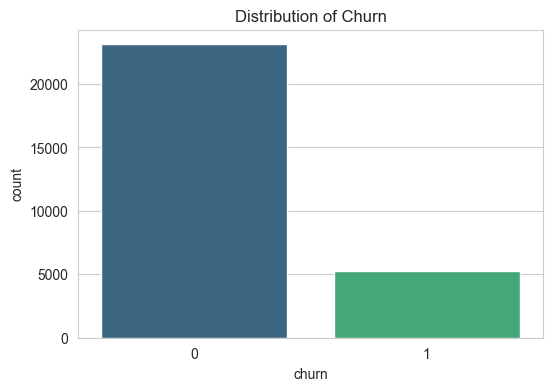

Overall Churn Rate: 18.53%


In [4]:
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Churn')
plt.show()

churn_rate = df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

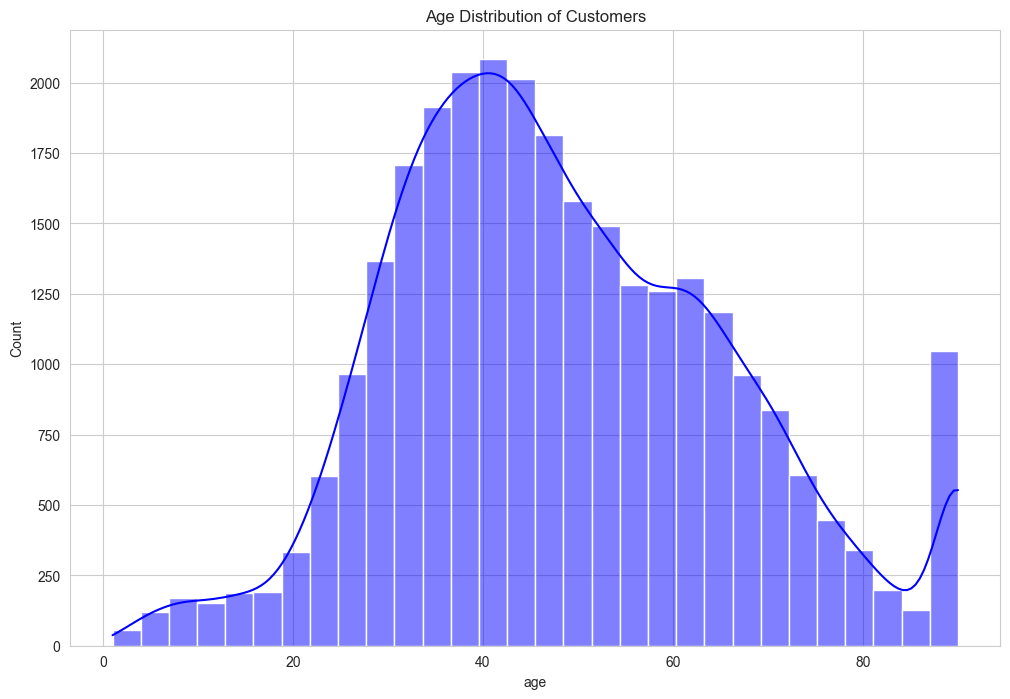

In [5]:
# Age Distribution
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution of Customers')
plt.show()

## 2. Bivariate Analysis

How does churn relate to other variables?

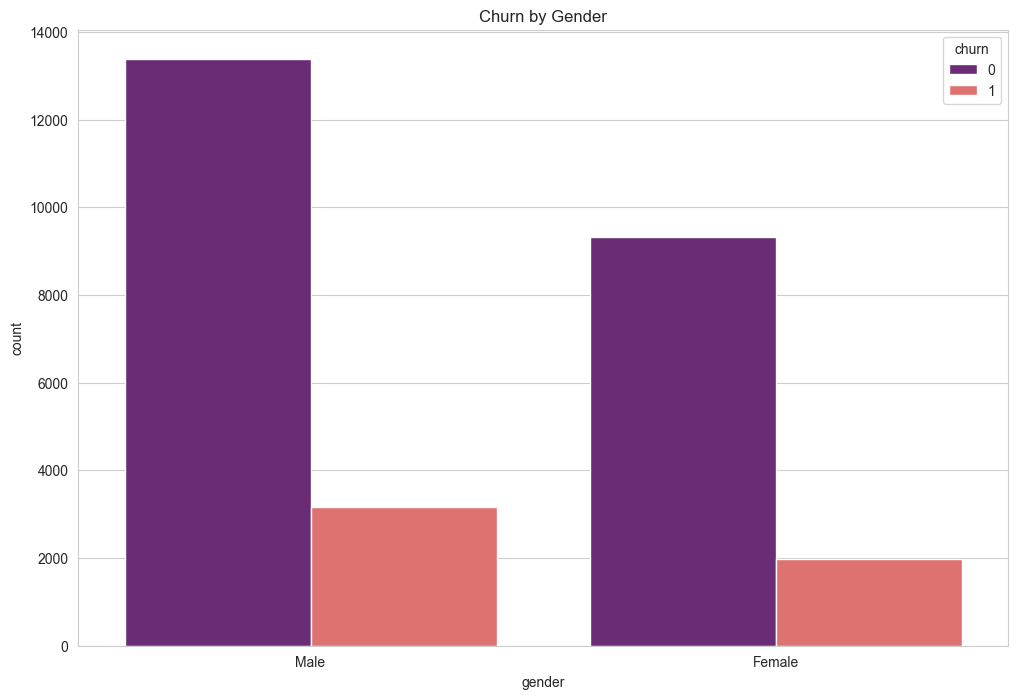

In [6]:
# Churn by Gender
sns.countplot(x='gender', hue='churn', data=df, palette='magma')
plt.title('Churn by Gender')
plt.show()

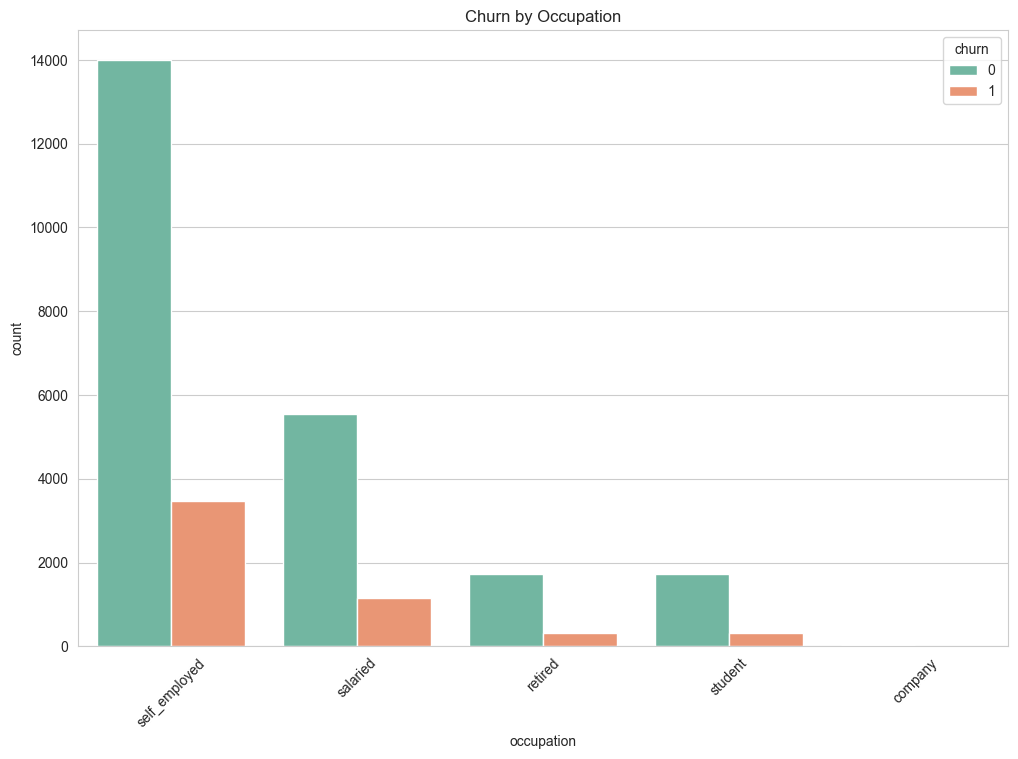

In [7]:
# Churn by Occupation
sns.countplot(x='occupation', hue='churn', data=df, palette='Set2')
plt.title('Churn by Occupation')
plt.xticks(rotation=45)
plt.show()

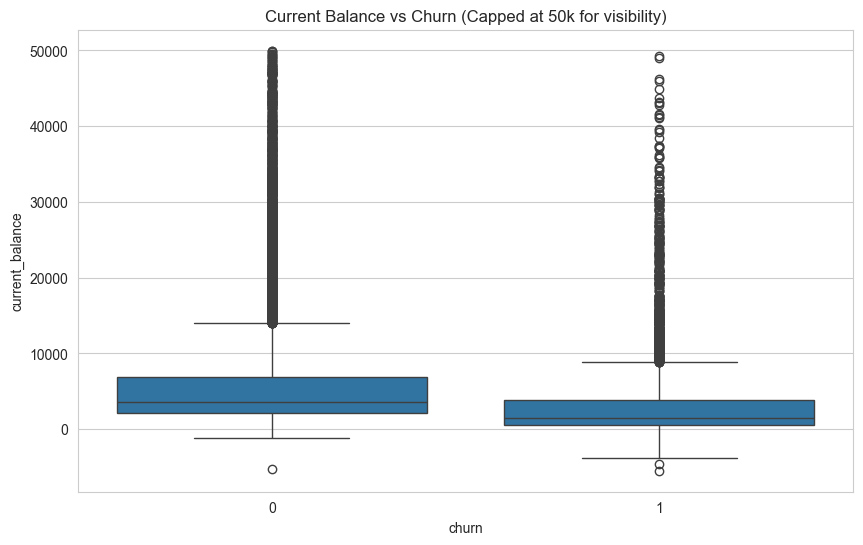

In [8]:
# Churn vs Current Balance
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='current_balance', data=df[df['current_balance'] < 50000])
plt.title('Current Balance vs Churn (Capped at 50k for visibility)')
plt.show()

## 3. Correlation Analysis

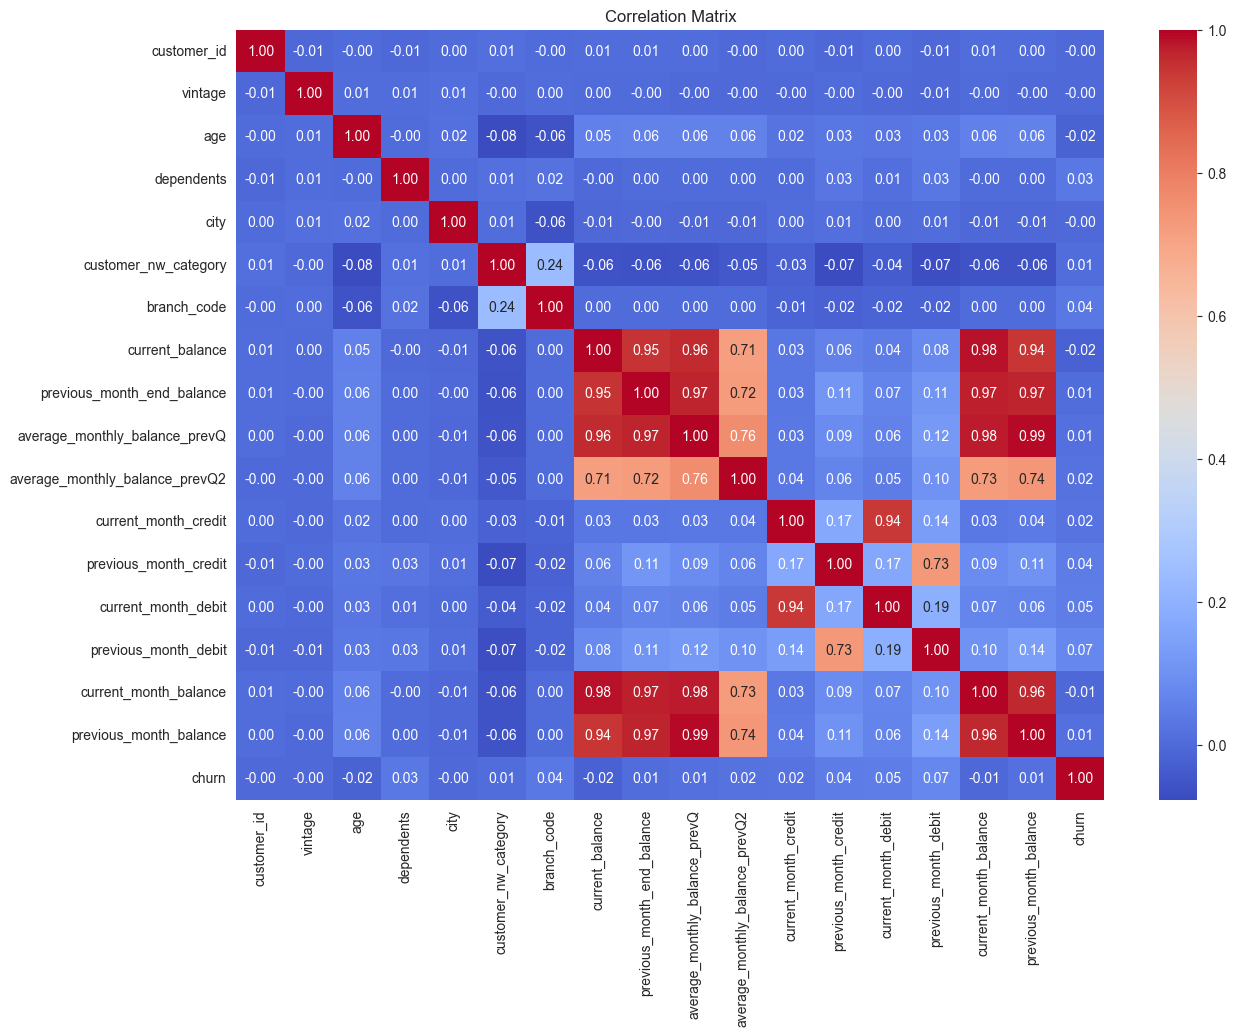

In [9]:
# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 4. Key Insights

1. **Churn Rate:** Roughly 18-20% of customers are churning.
2. **Balance Factor:** Lower balance customers show a higher tendency to churn.
3. **Occupation:** Self-employed individuals have a slightly different churn profile than salaried ones.
4. **Vintage:** Tenure affects loyalty; identifying the breaking point is key.